In [11]:
import os
import sys 
import astropy.units as u
import time 
import matplotlib.pyplot as plt
import pickle
import numpy as np
import pandas as pd

from outflows import ImageUtilities, Outflow, PlottingUtilities, RegionUtilities
from astropy.io import fits, ascii
from astropy.coordinates import SkyCoord
from astropy.stats import SigmaClip
from astropy.wcs import WCS

from astrodendro import Dendrogram
from astrodendro.analysis import PPStatistic
from photutils.background import StdBackgroundRMS
from matplotlib.widgets import Button, Slider
from glob import glob


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


This notebook goes through an example of estimating the position angle (PA) of an outflow in a NIRCam image of Serpens Main. Structures are identified in the image using an astrodendro-based pipeline and then interactively selected and stored to be used in the PA estimation.

In [2]:
%matplotlib widget

## Load images

In [3]:
G339_ALMA_hdu = fits.open("./example_images/G339_ALMA_B6_cont.fits")[0]
SerpensMain_NIRCam_hdu = fits.open("./example_images/SerpensMain_NIRCam_f480M.fits")[1]

## Define central coordinates of outflow we want to select structures for

We'll select structures for an outflow in a NIRCam F480M image of Serpens Main.

In [20]:
# Coordinates of driving source (or central position if none identified)
outflow_coords = SkyCoord(277.45296, 1.28233, unit=u.deg, frame='icrs')

# Angles the images need to be rotated by to make the outflow roughly horizontal
outflow_rotation_angle = -70


## Select dendrogram structures

New we'll select structures using an interactive tool. The tool starts by plotting the lowest-level structures, and the slider ccan be used to plot progressively higher-level structures. When the outflow features are isolated from the background emission and nearby sources, select the structures you want to assign to the outflow.

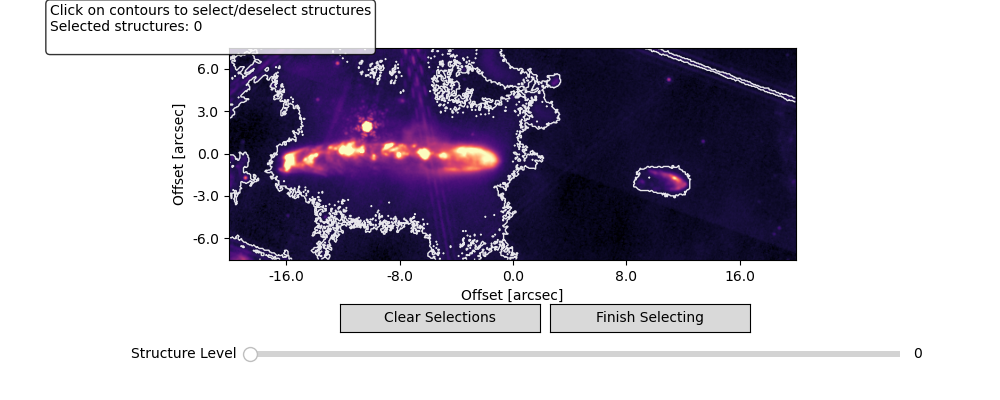

In [22]:
SerpensMain_noise = StdBackgroundRMS(sigma_clip=SigmaClip(sigma=2)).calc_background_rms(SerpensMain_NIRCam_hdu.data)
# outflow_rotation_angles = [-43.485810563886616, -55.08581056388661, -72.6858105638866]
outflow = Outflow(
        image_hdu=SerpensMain_NIRCam_hdu,
        central_coord=outflow_coords,
        rotation_angle=outflow_rotation_angle,
        window_x_arcsec=40,
        window_y_arcsec=15,
    )

dendrogram = outflow.compute_dendrogram(min_value_factor=2.5, min_npix=500, mask_bright=False, noise=SerpensMain_noise)
outflow.select_structures(dendrogram)


## Estimate outflow position angle (PA)

Now we'll compute the PA of each pixel in the selected strutures relative to the driving source and fit a Gaussian function to the distribution of pixel PAs to estimate an single outflow PA.

### Fit a single Gaussian to the distribution of pixel PAs

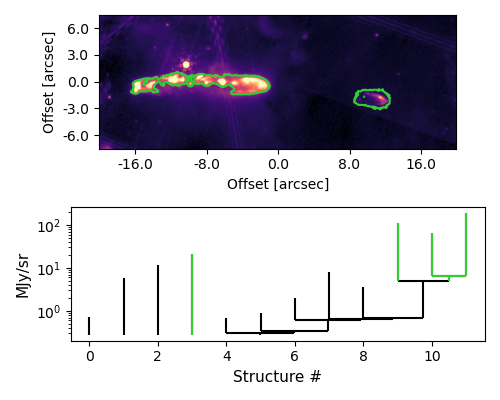

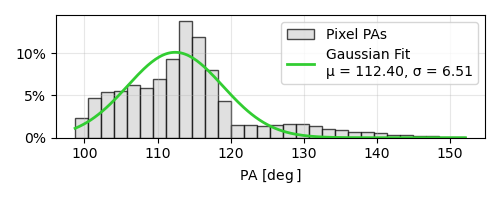

In [28]:
outflow.structure_plots(save_as= 'outflow' + str(i+1) + '_structures.png')
PA, PA_err, x_fit, y_fit, pix_pas = outflow.compute_PA(separate_lobes=False, figsize=(5,2), save_as='outflow' + str(i+1) + '_histogram.png')

We can also fit two Gaussian functions to accomodate bimodal distributions arising from outflow lobes with distinct orientations.

### Fit two Gaussians to account for differently oriented lobes

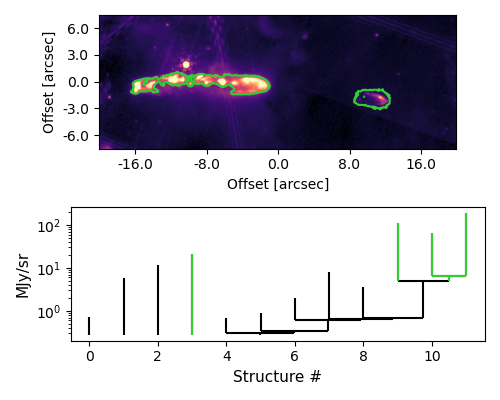

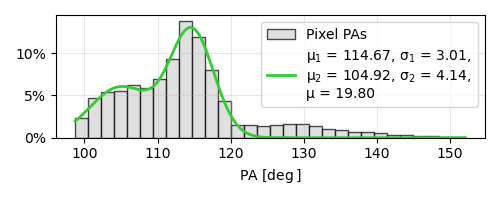

In [26]:
outflow.structure_plots(save_as= 'outflow' + str(i+1) + '_structures.png')
PA1, PA1_err, PA2, PA2_err, x_fit, y_fit, pix_pas = outflow.compute_PA(separate_lobes=True, figsize=(5,2), save_as='outflow' + str(i+1) + '_histogram.png')